In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Wine dataset

wine = load_wine()

print("Wine dataset loaded successfully!")

Wine dataset loaded successfully!


In [3]:
# Creating a Pandas DataFrame

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Adding the target column

df["Target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

In [5]:
# Statistical summary of the dataset

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
# Checking for missing values

df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [7]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 178
Columns : 14


In [8]:
# Displaying the target classes

print("Target Classes:")
print(wine.target_names)

print("\nUnique Target Values:")
print(np.unique(wine.target))

Target Classes:
['class_0' 'class_1' 'class_2']

Unique Target Values:
[0 1 2]


In [9]:
# Separating features and target

X = df.drop("Target", axis=1)
y = df["Target"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (178, 13)
Target Shape  : (178,)


In [10]:
# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (142, 13)
Testing Features  : (36, 13)
Training Target   : (142,)
Testing Target    : (36,)


In [11]:
# Standardizing the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully!")
print("Testing data scaled successfully!")

Training data scaled successfully!
Testing data scaled successfully!


In [12]:
# Creating the Linear Discriminant Analysis classifier

lda = LinearDiscriminantAnalysis()

print("LDA classifier created successfully!")

LDA classifier created successfully!


In [13]:
# Training the LDA classifier

lda.fit(X_train_scaled, y_train)

print("LDA classifier trained successfully!")

LDA classifier trained successfully!


In [14]:
# Making predictions on the test data

y_pred = lda.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [15]:
# Displaying actual and predicted classes

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(results.head(20))

,Actual,Predicted
0,0,0
1,2,2
2,0,0
3,1,0
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,2,2


In [16]:
# Calculating the accuracy of the LDA classifier

accuracy = accuracy_score(y_test, y_pred)

print("LDA Accuracy:", accuracy)
print("LDA Accuracy (%):", accuracy * 100)

LDA Accuracy: 0.9444444444444444
LDA Accuracy (%): 94.44444444444444


In [17]:
# Generating the classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [18]:
# Creating the confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]


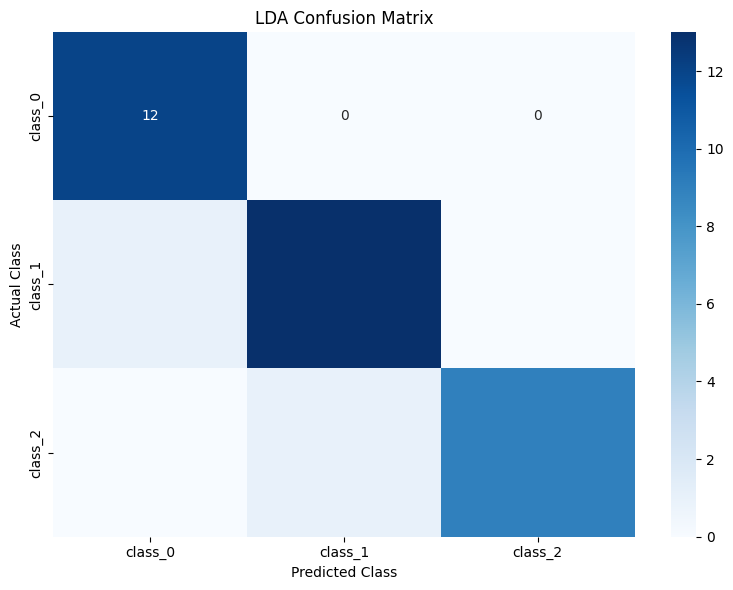

In [19]:
# Visualizing the confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.title("LDA Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [20]:
# Displaying important LDA model parameters

print("LDA Model:")
print(lda)

print("\nNumber of Classes:", lda.classes_)
print("Number of Components:", lda.scalings_.shape[1])

LDA Model:
LinearDiscriminantAnalysis()

Number of Classes: [0 1 2]
Number of Components: 2


In [21]:
# Evaluating LDA using cross-validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lda,
    X_train_scaled,
    y_train,
    cv=5
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean Cross-Validation Accuracy:",
      cv_scores.mean())

Cross-Validation Scores:
[1.         1.         1.         0.96428571 1.        ]

Mean Cross-Validation Accuracy: 0.9928571428571429


In [22]:
# Predicting class probabilities

y_proba = lda.predict_proba(X_test_scaled)

print("Class Probabilities:")
display(pd.DataFrame(
    y_proba,
    columns=wine.target_names
).head(10))

Class Probabilities:


,class_0,class_1,class_2
0,1.000000e+00,3.225398e-11,2.858180e-21
1,1.371262e-12,6.843518e-04,9.993156e-01
2,9.999992e-01,7.771523e-07,3.511985e-16
3,9.801449e-01,1.985511e-02,4.876739e-21
4,1.965101e-04,9.998035e-01,3.004314e-08
5,1.000000e+00,4.972309e-10,3.744817e-19
6,1.000000e+00,1.217445e-11,1.859787e-18
7,1.605859e-04,9.998394e-01,1.127456e-14
8,1.430692e-06,9.998156e-01,1.829347e-04
9,1.757143e-18,6.220180e-14,1.000000e+00


In [23]:
# Displaying predictions along with class probabilities

probability_results = pd.DataFrame(
    y_proba,
    columns=[
        f"Probability_{name}"
        for name in wine.target_names
    ]
)

probability_results["Actual"] = y_test.values
probability_results["Predicted"] = y_pred

display(probability_results.head(10))

,Probability_class_0,Probability_class_1,Probability_class_2,Actual,Predicted
0,1.000000e+00,3.225398e-11,2.858180e-21,0,0
1,1.371262e-12,6.843518e-04,9.993156e-01,2,2
2,9.999992e-01,7.771523e-07,3.511985e-16,0,0
3,9.801449e-01,1.985511e-02,4.876739e-21,1,0
4,1.965101e-04,9.998035e-01,3.004314e-08,1,1
5,1.000000e+00,4.972309e-10,3.744817e-19,0,0
6,1.000000e+00,1.217445e-11,1.859787e-18,0,0
7,1.605859e-04,9.998394e-01,1.127456e-14,1,1
8,1.430692e-06,9.998156e-01,1.829347e-04,1,1
9,1.757143e-18,6.220180e-14,1.000000e+00,2,2


In [24]:
# Checking correct and incorrect predictions

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

print("Correct Predictions:",
      results["Correct"].sum())

print("Incorrect Predictions:",
      (~results["Correct"]).sum())

Correct Predictions: 34
Incorrect Predictions: 2


In [25]:
# Calculating accuracy separately for each class

class_accuracy = {}

for class_value in np.unique(y_test):
    class_mask = y_test.values == class_value

    class_accuracy[class_value] = (
        y_pred[class_mask] == class_value
    ).mean()

print("Class-wise Accuracy:\n")

for class_value, score in class_accuracy.items():
    print(
        wine.target_names[class_value],
        ":",
        score
    )

Class-wise Accuracy:

class_0 : 1.0
class_1 : 0.9285714285714286
class_2 : 0.9


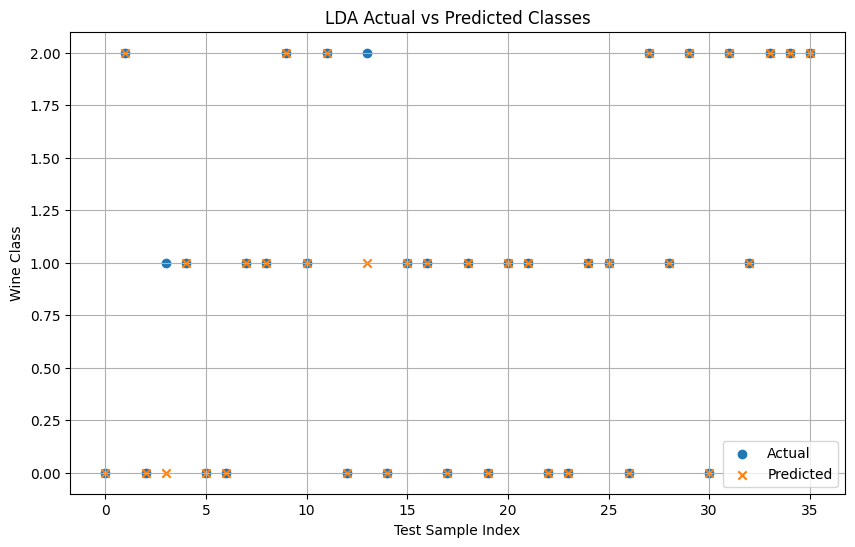

In [26]:
# Visualizing actual and predicted classes

plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    marker="o"
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    marker="x"
)

plt.title("LDA Actual vs Predicted Classes")
plt.xlabel("Test Sample Index")
plt.ylabel("Wine Class")

plt.legend()
plt.grid()
plt.show()

In [27]:
# Obtaining LDA decision scores

decision_scores = lda.decision_function(
    X_test_scaled
)

print("LDA Decision Scores:")

display(pd.DataFrame(
    decision_scores,
    columns=[
        f"Class_{class_value}"
        for class_value in lda.classes_
    ]
).head(10))

LDA Decision Scores:


,Class_0,Class_1,Class_2
0,14.050342,-10.107037,-33.253759
1,-23.654530,-3.626278,3.660075
2,6.864181,-7.203447,-28.720998
3,5.770207,1.870968,-40.979548
4,-9.380200,-0.845600,-18.166035
5,11.647651,-9.774315,-30.781093
6,12.707877,-12.423804,-28.118192
7,-5.555894,3.180628,-28.935439
8,-15.005446,-1.548278,-10.154476
9,-23.450490,-12.976040,17.432353


In [28]:
# Displaying the explained variance ratio of LDA components

if hasattr(lda, "explained_variance_ratio_"):
    print("LDA Explained Variance Ratio:")
    print(lda.explained_variance_ratio_)

    print(
        "\nTotal Variance Represented:",
        lda.explained_variance_ratio_.sum()
    )
else:
    print(
        "Explained variance ratio is not available "
        "for this LDA configuration."
    )

LDA Explained Variance Ratio:
[0.69352994 0.30647006]

Total Variance Represented: 1.0


In [29]:
# Transforming test data into LDA discriminant space

X_test_lda = lda.transform(X_test_scaled)

print("Original Test Shape :", X_test_scaled.shape)
print("LDA Test Shape      :", X_test_lda.shape)

Original Test Shape : (36, 13)
LDA Test Shape      : (36, 2)


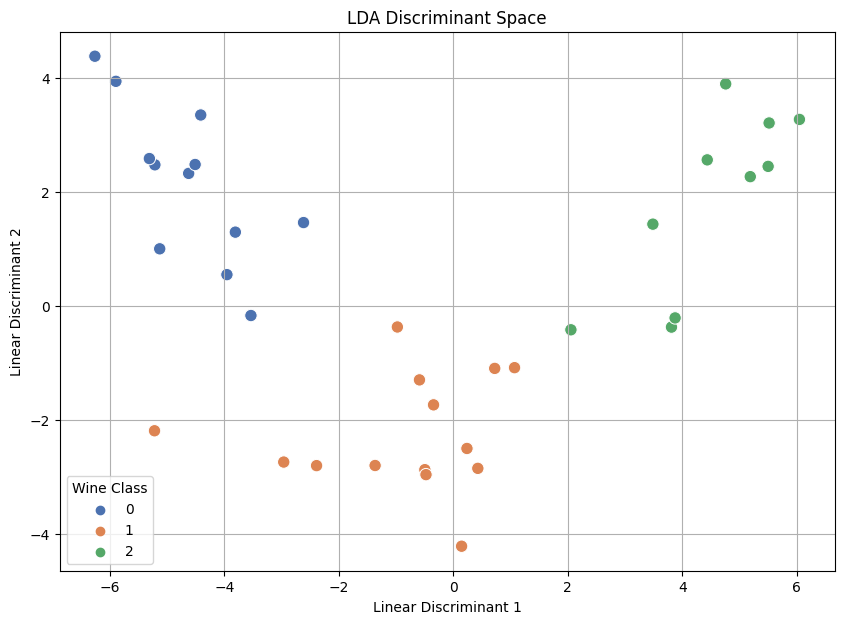

In [30]:
# Visualizing the LDA discriminant components

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_test_lda[:, 0],
    y=X_test_lda[:, 1],
    hue=y_test.values,
    palette="deep",
    s=80
)

plt.title("LDA Discriminant Space")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")

plt.grid()
plt.legend(title="Wine Class")

plt.show()